### LOADING AND CLEANING THE DATASET

In [1]:
import pandas as pd
df = pd.read_csv("D:/ML RESUME PROJECTS/Credit Risk Prediction/UCI_Credit_Card.csv")
df.head()


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Om\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Om\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_insta

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Om\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Om\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_insta

AttributeError: _ARRAY_API not found

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [2]:
df.shape

(30000, 25)

In [3]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [4]:
print(df["EDUCATION"].value_counts())
print(df["MARRIAGE"].value_counts())

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


In [5]:
# Replacing the unknown values in EDUCATION and MARRAIGE features since they dont make sense
df["EDUCATION"] = df["EDUCATION"].replace([0,5,6],4)

In [6]:
df["MARRIAGE"] = df["MARRIAGE"].replace(0,3)

In [7]:
print(df['EDUCATION'].value_counts())
print(df['MARRIAGE'].value_counts())

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64
MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64


#### The reason we do not remove all the unkown values is because we still have more important information in those rows other than the marraige or education features. 

### EDA

In [8]:
#checking the class imbalance
print(df["default.payment.next.month"].value_counts())

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64


In [9]:
print(df["default.payment.next.month"].value_counts(normalize=True)*100)

default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


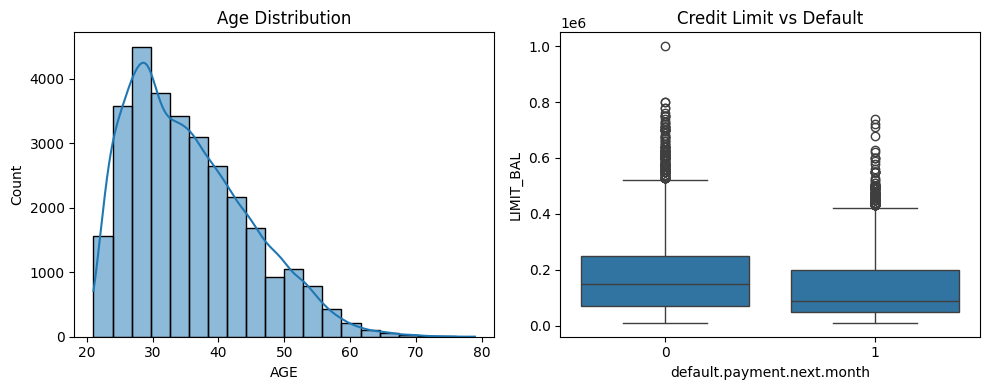

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Age
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['AGE'], bins=20, kde=True)
plt.title('Age Distribution')

# Credit Limit vs Default
plt.subplot(1,2,2)
sns.boxplot(x='default.payment.next.month', y='LIMIT_BAL', data=df)
plt.title('Credit Limit vs Default')
plt.tight_layout()
plt.show()

#### the conclusion we get from the boxplot is that more the credit limit , less the defaulters and vice versa. This makes total real world sense because banks personlly provide high credit limits by trusting people based on their income and financial stability because those people are less natural to default.

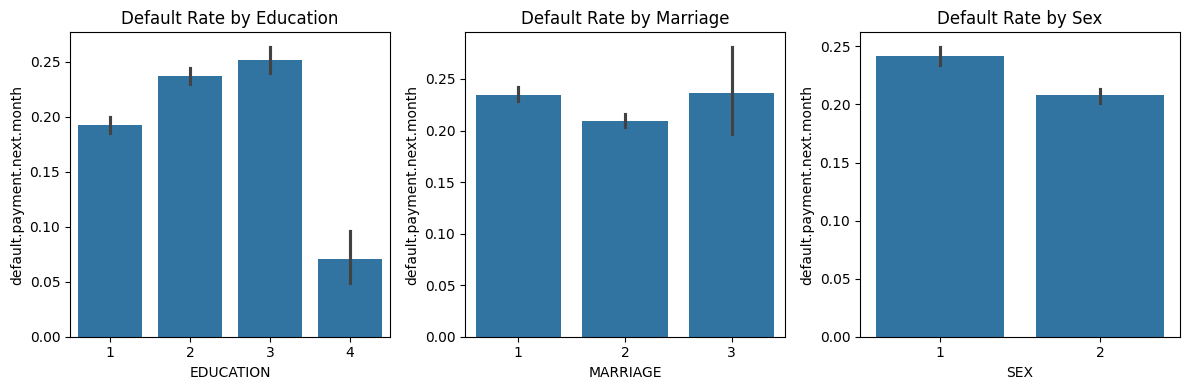

In [11]:
# Default rate by Education
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.barplot(x='EDUCATION', y='default.payment.next.month', data=df)
plt.title('Default Rate by Education')

# Default rate by Marriage
plt.subplot(1,3,2)
sns.barplot(x='MARRIAGE', y='default.payment.next.month', data=df)
plt.title('Default Rate by Marriage')

# Default rate by Sex
plt.subplot(1,3,3)
sns.barplot(x='SEX', y='default.payment.next.month', data=df)
plt.title('Default Rate by Sex')

plt.tight_layout()
plt.show()

#### We can see that people in category 3 i.e education completed till high school have more defaulters since low education means less paying jobs and hence tougher repayment.

#### We can see that the married people have more defaulters since extra financial expenditure on many factors such as children, household expenses come froward.

#### The gender difference is very less and hence gives very less information (males are more by looking at the graphs directly)

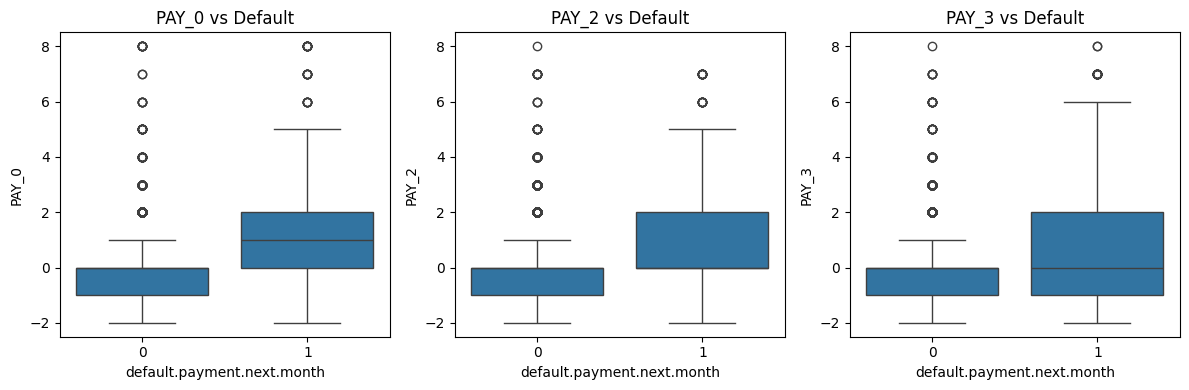

In [12]:
plt.figure(figsize=(12,4))
for i, col in enumerate(['PAY_0', 'PAY_2', 'PAY_3']):
    plt.subplot(1,3,i+1)
    sns.boxplot(x='default.payment.next.month', 
                y=col, data=df)
    plt.title(f'{col} vs Default')
plt.tight_layout()
plt.show()

In [13]:
print(df.groupby('default.payment.next.month')['PAY_0'].value_counts())

default.payment.next.month  PAY_0
0                            0       12849
                            -1        4732
                             1        2436
                            -2        2394
                             2         823
                             3          78
                             4          24
                             5          13
                             8           8
                             6           5
                             7           2
1                            0        1888
                             2        1844
                             1        1252
                            -1         954
                            -2         365
                             3         244
                             4          52
                             5          13
                             8          11
                             7           7
                             6           6
Name: count, dtype: 

### FEATURE ENGINEERING 

#### We have the columns BILL_AMT1...BILL_AMT6 i.e teh actual bill amount which is to be paid
#### Similarly we have PAY_AMT1...PAY_AMT6 i.e the amount which the person paid from the bill amount
#### Hence we can calculate the payment_ratio i.e the total percentage of how much amount has been paid from the bill amount
#### FORMULA - (PAY_AMT/(BILL_AMT + 1)) * 100 (the 1 in denominator is to prevent divison error if bill amount is actually 0)

In [14]:
# Payment Ratio for each month
df['PAY_RATIO1'] = df['PAY_AMT1'] / (df['BILL_AMT1'] + 1)
df['PAY_RATIO2'] = df['PAY_AMT2'] / (df['BILL_AMT2'] + 1)
df['PAY_RATIO3'] = df['PAY_AMT3'] / (df['BILL_AMT3'] + 1)
df['PAY_RATIO4'] = df['PAY_AMT4'] / (df['BILL_AMT4'] + 1)
df['PAY_RATIO5'] = df['PAY_AMT5'] / (df['BILL_AMT5'] + 1)
df['PAY_RATIO6'] = df['PAY_AMT6'] / (df['BILL_AMT6'] + 1)

# Average payment ratio across all 6 months
df['AVG_PAY_RATIO'] = (df['PAY_RATIO1'] + df['PAY_RATIO2'] + 
                       df['PAY_RATIO3'] + df['PAY_RATIO4'] + 
                       df['PAY_RATIO5'] + df['PAY_RATIO6']) / 6

print(df['AVG_PAY_RATIO'].describe())

count    2.996700e+04
mean              inf
std               NaN
min     -2.007396e+04
25%      3.943791e-02
50%      7.799799e-02
75%      1.170295e+00
max               inf
Name: AVG_PAY_RATIO, dtype: float64


C:\Users\Om\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [15]:
df.head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT5,PAY_AMT6,default.payment.next.month,PAY_RATIO1,PAY_RATIO2,PAY_RATIO3,PAY_RATIO4,PAY_RATIO5,PAY_RATIO6,AVG_PAY_RATIO
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,1,0.000000,0.222043,0.000000,0.000000,0.000000,0.000000,0.037007
1,2,120000.0,2,2,2,26,-1,2,0,0,...,0.0,2000.0,1,0.000000,0.579374,0.372717,0.305530,0.000000,0.613121,0.311790
2,3,90000.0,2,2,2,34,0,0,0,0,...,1000.0,5000.0,0,0.051915,0.106929,0.073746,0.069774,0.066894,0.321543,0.115134
3,4,50000.0,2,2,1,37,0,0,0,0,...,1069.0,1000.0,0,0.042561,0.041858,0.024345,0.038849,0.036913,0.033843,0.036395
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,689.0,679.0,0,0.232072,6.468171,0.279049,0.429779,0.035985,0.035490,1.246758
5,6,50000.0,1,1,2,37,0,0,0,0,...,1000.0,800.0,0,0.038819,0.031803,0.011404,0.051560,0.050968,0.039950,0.037417
6,7,500000.0,1,1,2,29,0,0,0,0,...,13750.0,13770.0,0,0.149470,0.097082,0.085392,0.037296,0.028468,0.029054,0.071127
7,8,100000.0,2,2,2,23,0,-1,-1,0,...,1687.0,1542.0,0,0.031995,1.577428,0.000000,2.617117,-10.677215,2.714789,-0.622648
8,9,140000.0,2,3,1,28,0,0,2,0,...,1000.0,1000.0,0,0.294967,0.000000,0.035676,0.081887,0.084789,0.268817,0.127689
9,10,20000.0,1,3,2,35,-2,-2,-2,-2,...,1122.0,0.0,0,0.000000,0.000000,0.000000,13007.000000,0.086255,0.000000,2167.847709


#### We can use the pay_0...pay_6 columns to find the total default but there is an issue. There are values such as -2 and 0 in the dataset which are actually not defined so we replace -2 with -1 since -2 basically stands for "credit card not used this month". Basically the bill amount will be 0 and payment amount will also be 0 which means the same as -1 i.e "amount is paid on time"

In [16]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df[pay_cols].replace(-2,-1)

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
0,2,2,-1,-1,-1,-1
1,-1,2,0,0,0,2
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,-1,0,-1,0,0,0
...,...,...,...,...,...,...
29995,0,0,0,0,0,0
29996,-1,-1,-1,-1,0,0
29997,4,3,2,-1,0,0
29998,1,-1,0,0,0,-1


In [17]:
# Create total delay feature
df['TOTAL_DELAY'] = df[['PAY_0', 'PAY_2', 
                          'PAY_3', 'PAY_4', 
                          'PAY_5', 'PAY_6']].sum(axis=1)

In [18]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT6,default.payment.next.month,PAY_RATIO1,PAY_RATIO2,PAY_RATIO3,PAY_RATIO4,PAY_RATIO5,PAY_RATIO6,AVG_PAY_RATIO,TOTAL_DELAY
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,1,0.000000,0.222043,0.000000,0.000000,0.000000,0.000000,0.037007,-2
1,2,120000.0,2,2,2,26,-1,2,0,0,...,2000.0,1,0.000000,0.579374,0.372717,0.305530,0.000000,0.613121,0.311790,3
2,3,90000.0,2,2,2,34,0,0,0,0,...,5000.0,0,0.051915,0.106929,0.073746,0.069774,0.066894,0.321543,0.115134,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,1000.0,0,0.042561,0.041858,0.024345,0.038849,0.036913,0.033843,0.036395,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,679.0,0,0.232072,6.468171,0.279049,0.429779,0.035985,0.035490,1.246758,-2


In [19]:


print(df['TOTAL_DELAY'].describe())

count    30000.000000
mean        -1.094633
std          5.893055
min        -12.000000
25%         -5.000000
50%          0.000000
75%          0.000000
max         36.000000
Name: TOTAL_DELAY, dtype: float64


In [20]:
print(df.groupby('default.payment.next.month')['TOTAL_DELAY'].mean())

default.payment.next.month
0   -1.980140
1    2.023056
Name: TOTAL_DELAY, dtype: float64


#### Feature Engineering is now complete. Here's what we've created:

#### PAY_RATIO1 to PAY_RATIO6 — payment ratio per month 
#### AVG_PAY_RATIO — average payment behaviour across 6 months 
#### TOTAL_DELAY — overall payment delay behaviour 

In [21]:
df["PAY_RATIO1"].isnull().sum()

np.int64(8)

In [22]:
df.shape

(30000, 33)

In [23]:
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month', 'PAY_RATIO1', 'PAY_RATIO2', 'PAY_RATIO3', 'PAY_RATIO4', 'PAY_RATIO5', 'PAY_RATIO6', 'AVG_PAY_RATIO', 'TOTAL_DELAY']


#### DROPPING UNNECESSARY COLUMNS 

In [24]:
drop_cols = ['ID', 'BILL_AMT1','BILL_AMT2', 'BILL_AMT3','BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6','PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

df.drop(columns=drop_cols,inplace=True)

In [25]:
print(df.shape)
print(df.columns.tolist())


(30000, 20)
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default.payment.next.month', 'PAY_RATIO1', 'PAY_RATIO2', 'PAY_RATIO3', 'PAY_RATIO4', 'PAY_RATIO5', 'PAY_RATIO6', 'AVG_PAY_RATIO', 'TOTAL_DELAY']


In [26]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,default.payment.next.month,PAY_RATIO1,PAY_RATIO2,PAY_RATIO3,PAY_RATIO4,PAY_RATIO5,PAY_RATIO6,AVG_PAY_RATIO,TOTAL_DELAY
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,1,0.000000,0.222043,0.000000,0.000000,0.000000,0.000000,0.037007,-2
1,120000.0,2,2,2,26,-1,2,0,0,0,2,1,0.000000,0.579374,0.372717,0.305530,0.000000,0.613121,0.311790,3
2,90000.0,2,2,2,34,0,0,0,0,0,0,0,0.051915,0.106929,0.073746,0.069774,0.066894,0.321543,0.115134,0
3,50000.0,2,2,1,37,0,0,0,0,0,0,0,0.042561,0.041858,0.024345,0.038849,0.036913,0.033843,0.036395,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,0,0,0.232072,6.468171,0.279049,0.429779,0.035985,0.035490,1.246758,-2


## MODEL BUIDING

In [27]:
# train test split 

from sklearn.model_selection import train_test_split

X = df.drop(columns=["default.payment.next.month"])
y = df["default.payment.next.month"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Training size: ",X_train.shape)
print("Testing size: ",X_test.shape)
print("Target Distribution in train set: ",y_train.value_counts(normalize=True)*100)
print("Target Distribution in test set: ",y_test.value_counts(normalize=True)*100)

Training size:  (24000, 19)
Testing size:  (6000, 19)
Target Distribution in train set:  default.payment.next.month
0    77.879167
1    22.120833
Name: proportion, dtype: float64
Target Distribution in test set:  default.payment.next.month
0    77.883333
1    22.116667
Name: proportion, dtype: float64


In [28]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\Om\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [29]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)
X_train_smote , Y_train_smote = smote.fit_resample(X_train,y_train)

print("Before SMOTE: ", y_train.value_counts())
print("After SMOTE: ", Y_train_smote.value_counts())

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

#### we get an error here because there are some nan values produced in the ratio columns. these nan values occurede due to extremely large payment values being divided by extremely large bill values which lead to an almsot infinity value. hnece we need to replace these Nan values by 0

In [30]:
print(X_train.isnull().sum())

LIMIT_BAL         0
SEX               0
EDUCATION         0
MARRIAGE          0
AGE               0
PAY_0             0
PAY_2             0
PAY_3             0
PAY_4             0
PAY_5             0
PAY_6             0
PAY_RATIO1        7
PAY_RATIO2       11
PAY_RATIO3       10
PAY_RATIO4       11
PAY_RATIO5       14
PAY_RATIO6       13
AVG_PAY_RATIO    28
TOTAL_DELAY       0
dtype: int64


In [31]:
import numpy as np

# Replace inf and -inf with NaN first, then fill with 0
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Now fill remaining NaN with 0
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Verify - both should print 0
print("Train NaN count:", X_train.isnull().sum().sum())
print("Test NaN count:", X_test.isnull().sum().sum())

# Also verify no inf remaining
print("Train inf count:", np.isinf(X_train).sum().sum())
print("Test inf count:", np.isinf(X_test).sum().sum())

Train NaN count: 0
Test NaN count: 0
Train inf count: 0
Test inf count: 0


In [32]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)
X_train_smote , Y_train_smote = smote.fit_resample(X_train,y_train)

print("Before SMOTE: ", y_train.value_counts())
print("After SMOTE: ", Y_train_smote.value_counts())

Before SMOTE:  default.payment.next.month
0    18691
1     5309
Name: count, dtype: int64
After SMOTE:  default.payment.next.month
0    18691
1    18691
Name: count, dtype: int64


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Scale the data - important for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Train all 3 models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

for name, model in models.items():
    model.fit(X_train_scaled, Y_train_smote)
    y_pred = model.predict(X_test_scaled)
    print(f"\n{'='*50}")
    print(f"{name}")
    print('='*50)
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_pred):.4f}")



Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.71      0.78      4673
           1       0.36      0.58      0.45      1327

    accuracy                           0.68      6000
   macro avg       0.61      0.65      0.61      6000
weighted avg       0.75      0.68      0.70      6000

ROC-AUC: 0.6462

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      4673
           1       0.49      0.48      0.49      1327

    accuracy                           0.77      6000
   macro avg       0.67      0.67      0.67      6000
weighted avg       0.77      0.77      0.77      6000

ROC-AUC: 0.6700

XGBoost
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      4673
           1       0.45      0.49      0.47      1327

    accuracy                           0.76      6000
   macro avg       0.65      0.66      0.66      60

In [34]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_scaled, Y_train_smote)
y_pred_xgb = xgb.predict(X_test_scaled)

print("XGBoost")
print('='*50)
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_xgb):.4f}")

XGBoost
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      4673
           1       0.45      0.49      0.47      1327

    accuracy                           0.76      6000
   macro avg       0.65      0.66      0.66      6000
weighted avg       0.76      0.76      0.76      6000

ROC-AUC: 0.6611


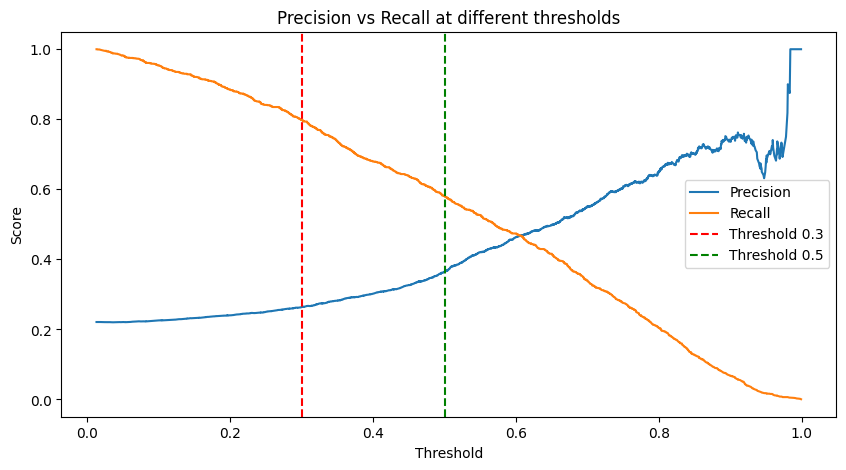

At threshold 0.3:
              precision    recall  f1-score   support

           0       0.87      0.37      0.52      4673
           1       0.26      0.80      0.40      1327

    accuracy                           0.46      6000
   macro avg       0.56      0.58      0.46      6000
weighted avg       0.73      0.46      0.49      6000



In [35]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Get probabilities instead of hard predictions
lr_model = models['Logistic Regression']
y_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate precision and recall at different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(x=0.3, color='red', linestyle='--', label='Threshold 0.3')
plt.axvline(x=0.5, color='green', linestyle='--', label='Threshold 0.5')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at different thresholds')
plt.legend()
plt.show()

# Show metrics at threshold 0.3
y_pred_03 = (y_probs >= 0.3).astype(int)
print("At threshold 0.3:")
print(classification_report(y_test, y_pred_03))

In [36]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\Om\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [37]:
import shap

rf_model = models['Random Forest']

# Use only 500 samples instead of full test set
X_test_sample = X_test_scaled[:500]

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_sample)

shap.summary_plot(shap_values[1], X_test_sample,
                  feature_names=X_train.columns.tolist())

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.